# LIKWID policy-* summary

Run this notebook from a policy folder such as `performance/` or `ondemand/`.
It auto-detects subfolders like `<policy>-*` and computes:
- Total runtime [s]
- Average total power [W]
- Total energy [J]
- EDP [J*s]

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings
base_dir = Path('.')  # run from policy folder (e.g., performance/, ondemand/)
policy_name = base_dir.resolve().name
subfolder_pattern = f'{policy_name}-*'
benchmark_name = None  # None => process all detected benchmarks; set to a name to filter
skip_initial = 3
output_dir = base_dir  # per-benchmark CSV files are written here


In [2]:
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'tests' / 'common' / 'process_profiles_lib.py').is_file():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate tests/common/process_profiles_lib.py from current notebook path')

lib_dir = repo_root / 'tests' / 'common'
if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

from process_profiles_lib import (
    SUM_FIELDS,
    build_policy_summary,
    extract_job_id,
    find_stdout_for_job,
    list_profiles,
    load_likwid_profile,
    newest_profile_for_benchmark,
    plot_benchmark_boxplots,
    plot_likwid_timeseries,
    print_policy_context,
    run_has_fatal_error,
    summarize_profile,
)


In [3]:
per_benchmark_summary, all_output = build_policy_summary(
    base_dir=base_dir,
    subfolder_pattern=subfolder_pattern,
    benchmark_name=benchmark_name,
    skip_initial=skip_initial,
    output_dir=output_dir,
    policy_name=policy_name,
)

print_policy_context(policy_name, subfolder_pattern, benchmark_name)
all_output


Removed 41 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Removed 4 extreme-high LIKWID samples using automatic power filtering
Skipping turbo-performance-0/fotonik3d: found fatal error markers in speccpu_fotonik3d.37661.prof
Removed 2 extreme-high LIKWID samples using automatic power filtering
Removed 4 extreme-high LIKWID samples using automatic power filtering
Removed 13 extreme-high LIKWID samples using automatic power filtering
Removed 55 extreme-high LIKWID samples using automatic power filtering
Removed 9 extreme-high LIKWID samples using automatic power filtering
Skipping turbo-performance-0/perlbench: found fatal error markers in speccpu_perlbench.37667.out
Removed 38 extreme-high LIKWID samples using automatic power filtering
Removed 38 extreme-high LIKWID samples using automatic power filtering
Skipping turbo-performance-0/x264: found fatal error markers in speccpu_x264.37670.prof
Skipping tur

,subfolder,benchmark,Total runtime [s],Average total power [W],Total energy [J],EDP [J*s]
0,Average,cam4,3838.72,612.83,2350798.85,9.020074e+09
1,turbo-performance-0,cam4,3817.82,691.17,2638075.71,1.007171e+10
2,turbo-performance-1,cam4,3864.85,522.81,2020299.79,7.808161e+09
3,turbo-performance-2,cam4,3829.39,741.05,2837040.02,1.086413e+10
4,turbo-performance-3,cam4,3837.19,550.01,2109676.30,8.095234e+09
...,...,...,...,...,...,...
58,turbo-performance-0,xz,2183.66,480.34,1050601.38,2.294159e+09
59,turbo-performance-1,xz,1949.75,636.92,1245185.95,2.427801e+09
60,turbo-performance-2,xz,1964.82,663.43,1306943.87,2.567904e+09
61,turbo-performance-3,xz,1951.74,650.09,1271491.13,2.481625e+09


Removed 41 extreme-high samples from 'Power L3 [W]' using upper bound 1.01e+03


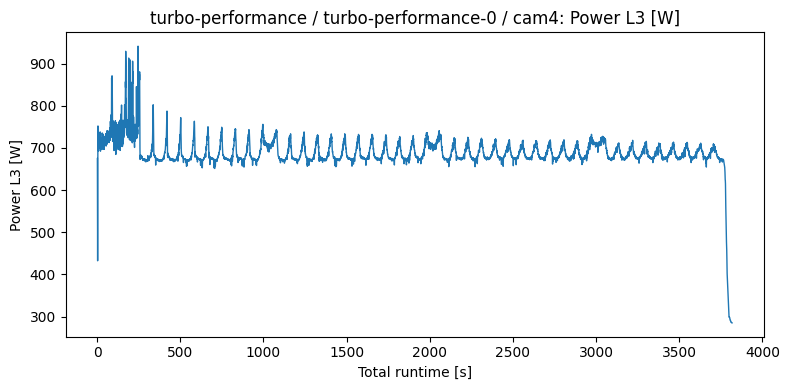

In [4]:
# Plot LIKWID sample time-series for one subfolder/benchmark and one field
selected_subfolder = 'turbo-performance-0'
selected_benchmark = None  # None => auto-pick first benchmark found in selected_subfolder
selected_field = 'Power L3 [W]'

plot_likwid_timeseries(
    base_dir=base_dir,
    selected_subfolder=selected_subfolder,
    selected_benchmark=selected_benchmark,
    selected_field=selected_field,
    skip_initial=skip_initial,
    policy_name=policy_name,
    include_benchmark_in_title=True,
)


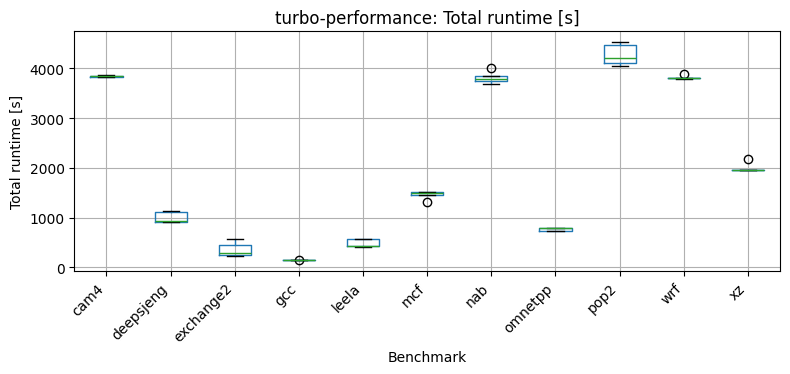

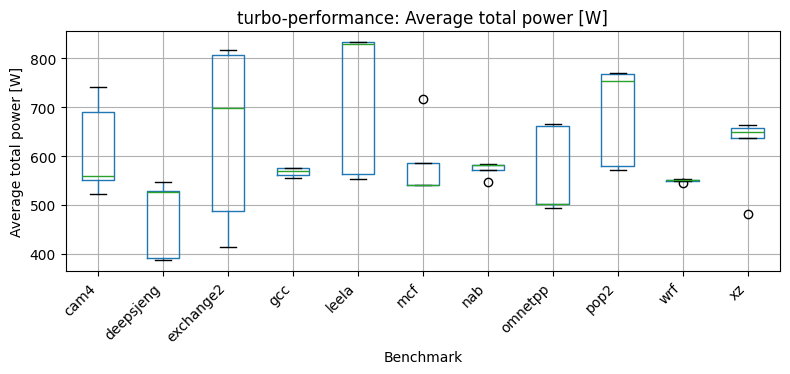

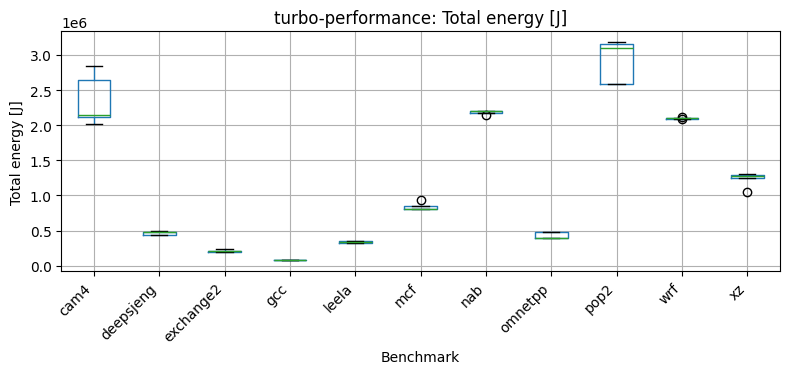

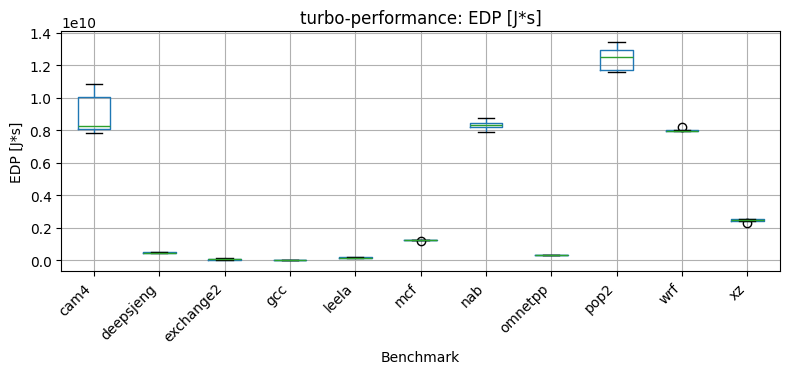

In [5]:
plot_metrics = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

plot_benchmark_boxplots(
    per_benchmark_summary=per_benchmark_summary,
    policy_name=policy_name,
    plot_metrics=plot_metrics,
)
